## A Trilha da Acadêmica - Notebook didático: Redes Neurais Recorrentes (RNN)
*Redes Neurais e Algoritimos Genéticos - Samarah Ramos*

### O que é uma RNN?

Uma rede neural recorrente é uma rede treinada com dados sequenciais ou séries temporais capaz de fazer previsões sequenciais de acordo com os dados recebidos. Ela pode ser usada para prever os próximos valores do Real se for treinada com seus valores anteriores.

Elas também podem ser usadas para resolver problemas ordinais (onde a ordem importa) ou temporais, como tradução de idiomas, análise de sentimentos e geração de legenda para imagens.

### Como uma RNN funciona?

Uma RNN diferente de outras redes neurais como MLPs possui memória, ou seja, informações anteriores influenciam em suas previsões atuais. Elas não consideram os dados independentes, mas sim sequências de informações.

Em redes neurais tradicionais, a saída de um neurônio é a entrada multiplicada pelo peso e pela função de ativação, mas em RNNs essa saída é enviada de volta para si mesma várias vezes, a quantidade de tempos que essa saída é enviada de volta é o chamado intervalo de tempo.

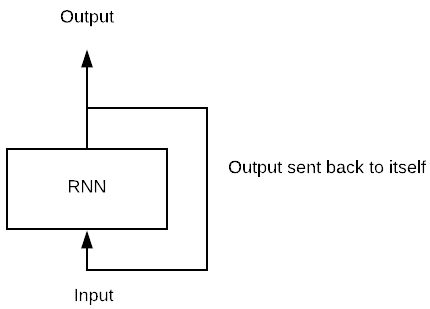

Além disso, elas usam o mesmo conjunto de peso em todas as camadas, mas esses pesos são ajustados de acordo com a retropropagação (backpropagation) e o gradiente descendente.

BPTT (Backpropagation Through Time) é o tipo de retropropagação presente em redes neurais recorrentes, ele calcula o quanto cada peso contribui para o erro, compartilhando pesos de um tempo para outro, e assim o gradiente descendente atualiza o peso de forma a minimizar esse erro.

### O que é a desaparição do gradiente ou sua explosão?

Os gradientes podem desaparecer ou explodir porque a multiplicação repetida dos pesos ao longo do tempo faz os gradientes tenderem a zero (impedindo aprendizado de longo prazo) ou ao infinito (quebrando o modelo).

### Alguns tipos de RNNs existem?

**RNN Clássica (Elman Network):** Estrutura básica de uma RNN. Trabalha bem apenas com sequências curtas, memória curta.

**LSTM (Long Short-Term Memory):** Controla as informações de entrada, células de memória com portas (input, forget, output), aprende o que deve lembrar e o que deve esquecer e é capaz de guardar informações por longos passos.

**GRU (Gated Recurrent Unit):** Versão simplificada da LSTM, porém com menos portas e parâmetros, por isso contuma possuir um treinamento mais rápido.

**RNN Bidirecional (BiRNN):** Processa a sequência em duas direções (forward e backward) usando duas camadas ocultas independentes (útil para determinar o contexto de palavras em frases, por exemplo).

## Tratando dados 
Como uma RNN trabalha com sequências e séries temporais, dados em que a ordem importa, ao trata-los é importante tomar cuidado para não perder essa informação. Os dados devem estar divididos em passos de tempos iguais (batches uniformes) e normalizados, pois RNNs são muito sensíveis a escalas diferentes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregar arquivo por arquivo
df1 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Wanshouxigong_20130301-20170228.csv")
df2 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Shunyi_20130301-20170228.csv")
df3 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Tiantan_20130301-20170228.csv")
df4 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Wanliu_20130301-20170228.csv")
df5 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Gucheng_20130301-20170228.csv")
df6 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Huairou_20130301-20170228.csv")
df7 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Nongzhanguan_20130301-20170228.csv")
df8 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Dingling_20130301-20170228.csv")
df9 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Dongsi_20130301-20170228.csv")
df10 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Guanyuan_20130301-20170228.csv")
df11 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df12 = pd.read_csv(r"C:\Users\samarah25011\Downloads\Arquivos_AirQuality_RNN\PRSA_Data_Changping_20130301-20170228.csv")

df12

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,28.0,47.0,4.0,14.0,300.0,NaN,11.7,1008.9,-13.3,0.0,NNE,1.3,Changping
35060,35061,2017,2,28,20,12.0,12.0,3.0,23.0,500.0,64.0,10.9,1009.0,-14.0,0.0,N,2.1,Changping
35061,35062,2017,2,28,21,7.0,23.0,5.0,17.0,500.0,68.0,9.5,1009.4,-13.0,0.0,N,1.5,Changping
35062,35063,2017,2,28,22,11.0,20.0,3.0,15.0,500.0,72.0,7.8,1009.6,-12.6,0.0,NW,1.4,Changping


### Removendo colunas com baixa correlação

Colunas irrelevantes para o desempenho da rede neural são excluídas nessa etapa, como data, hora e colunas que possuem baixa correlação com o target, como wd (direção do vento) nesse caso que é uma variável muito complexa para se trabalhar e que seu efeito pode ser encontrado com outras variáveis mais práticas de se trabalhar.

In [3]:
ATRIBUTOS = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',  # poluentes
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'       # meteorológicas
]
TARGET = ['PM2.5']  # ou o poluente que você quiser prever

# Carregar dados (excluindo a coluna wd automaticamente)
df_estacao_1 = df1[ATRIBUTOS + TARGET]
df_estacao_2 = df2[ATRIBUTOS + TARGET]
df_estacao_3 = df3[ATRIBUTOS + TARGET]
df_estacao_4 = df4[ATRIBUTOS + TARGET]
df_estacao_5 = df5[ATRIBUTOS + TARGET]
df_estacao_6 = df6[ATRIBUTOS + TARGET]
df_estacao_7 = df7[ATRIBUTOS + TARGET]
df_estacao_8 = df8[ATRIBUTOS + TARGET]
df_estacao_9 = df9[ATRIBUTOS + TARGET]
df_estacao_10 = df10[ATRIBUTOS + TARGET]
df_estacao_11 = df11[ATRIBUTOS + TARGET]
df_estacao_12 = df12[ATRIBUTOS + TARGET]

In [4]:
dataframes = [df_estacao_1, df_estacao_2, df_estacao_3, df_estacao_4,
              df_estacao_5, df_estacao_6, df_estacao_7, df_estacao_8,
              df_estacao_9, df_estacao_10, df_estacao_11, df_estacao_12]

### Substituindo dados faltantes

Dados faltantes não podem ser excluídos, pois isso geraria uma quebra nas sequências temporais, por isso, utiliza-se métodos para susbtitui-los por valores sintéticos que buscam se aproximar da realidade. 

A técnica utilizada aqui foi a de `imputação sequencial`, em que se substitui um valor faltante em determinado instante t pela média aritmética dos K valores anteriores imediatamente disponíveis (não faltantes) na mesma série temporal.

In [5]:
def substituir_pela_media(dataset, janela):
    
    df_limpo = dataset.copy()

    for coluna in df_limpo.columns:

        # Calcular média móvel
        media = df_limpo[coluna].rolling(window=janela, center=False, min_periods=1).mean()

        # Preencher com média móvel
        df_limpo[coluna] = df_limpo[coluna].fillna(media)
        
        # Se ainda tiver NaN, preencher com o último valor válido
        df_limpo[coluna] = df_limpo[coluna].fillna(method='ffill')
        
        # Se ainda tiver NaN, preencher com o próximo valor válido
        df_limpo[coluna] = df_limpo[coluna].fillna(method='bfill')
        
        # Se ainda tiver NaN, preencher com a média da coluna toda
        if df_limpo[coluna].isna().any():
            df_limpo[coluna] = df_limpo[coluna].fillna(df_limpo[coluna].mean())

    return df_limpo

In [6]:
dts_processados = []
for i in dataframes:
    dt_processado = substituir_pela_media(i, 6)
    dts_processados.append(dt_processado)
    
df_estacao_1 = dts_processados[0]
df_estacao_2 = dts_processados[1]
df_estacao_3 = dts_processados[2]
df_estacao_4 = dts_processados[3]
df_estacao_5 = dts_processados[4]
df_estacao_6 = dts_processados[5]
df_estacao_7 = dts_processados[6]
df_estacao_8 = dts_processados[7]
df_estacao_9 = dts_processados[8]
df_estacao_10 = dts_processados[9]
df_estacao_11 = dts_processados[10]
df_estacao_12 = dts_processados[11]

C:\Users\samarah25011\AppData\Local\Temp\ipykernel_4208\2368634970.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_limpo[coluna] = df_limpo[coluna].fillna(method='ffill')
C:\Users\samarah25011\AppData\Local\Temp\ipykernel_4208\2368634970.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_limpo[coluna] = df_limpo[coluna].fillna(method='bfill')


In [7]:
# Verificando se a substituição mudou todos os NaN
valores_faltantes = df_estacao_12.isnull().sum()

faltantes = pd.DataFrame({
    'Coluna': valores_faltantes.index,
    'Valores Ausentes': valores_faltantes.values,
})

print("Valores ausentes por coluna:")
print(faltantes[faltantes['Valores Ausentes'] > 0])
print(f"\nDF Total: {len(df_estacao_12)}")

Valores ausentes por coluna:
Empty DataFrame
Columns: [Coluna, Valores Ausentes]
Index: []

DF Total: 35064


## Divisão em treino, validação e teste

Aqui os dados são dividos entre treino, validação e teste. É importante observar que as identificações de cada estação foram removidos antes, mas é importante traze-los de volta pois há horários iguais em todas as estações e essa diferenciação espacial é impotante para o modelo.

In [8]:
# Antes de concatenar, adicionar identificador de estação
todas_estacoes = {
    'Wanshouxigong': df_estacao_1,
    'Dongsi': df_estacao_2,
    'Guanyuan': df_estacao_3,
    'Gucheng': df_estacao_4,
    'Huairou': df_estacao_5,
    'Nongzhanguan': df_estacao_6,
    'Shunyi': df_estacao_7,
    'Tiantan': df_estacao_8,
    'Wanliu': df_estacao_9,
    'Changping': df_estacao_10,
    'Dingling': df_estacao_11,
    'Miyun': df_estacao_12
}

# Adicionar identificador numérico para cada estação
dts_com_id = []

for i, (nome, df) in enumerate(todas_estacoes.items()):
    df = df.copy()
    df['estacao_id'] = i 
    dts_com_id.append(df)
    print(f"{nome} -> ID: {i}")

# Concatenar tudo
df = pd.concat(dts_com_id, ignore_index=True)

print(f"\nDataset final: {df.shape}")
print(f"IDs das estações: {df['estacao_id'].unique()}")

Wanshouxigong -> ID: 0
Dongsi -> ID: 1
Guanyuan -> ID: 2
Gucheng -> ID: 3
Huairou -> ID: 4
Nongzhanguan -> ID: 5
Shunyi -> ID: 6
Tiantan -> ID: 7
Wanliu -> ID: 8
Changping -> ID: 9
Dingling -> ID: 10
Miyun -> ID: 11

Dataset final: (420768, 12)
IDs das estações: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [9]:
df

,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,PM2.5,estacao_id
0,9.0,6.0,17.00,200.0,62.000000,0.3,1021.9,-19.0,0.0,2.0,9.0,0
1,11.0,7.0,14.00,200.0,66.000000,-0.1,1022.4,-19.3,0.0,4.4,11.0,0
2,8.0,6.5,16.00,200.0,59.000000,-0.6,1022.6,-19.7,0.0,4.7,8.0,0
3,8.0,3.0,16.00,200.0,62.333333,-0.7,1023.5,-20.9,0.0,2.6,8.0,0
4,8.0,3.0,15.75,300.0,36.000000,-0.9,1024.1,-21.7,0.0,2.5,8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
420763,47.0,4.0,14.00,300.0,52.600000,11.7,1008.9,-13.3,0.0,1.3,28.0,11
420764,12.0,3.0,23.00,500.0,64.000000,10.9,1009.0,-14.0,0.0,2.1,12.0,11
420765,23.0,5.0,17.00,500.0,68.000000,9.5,1009.4,-13.0,0.0,1.5,7.0,11
420766,20.0,3.0,15.00,500.0,72.000000,7.8,1009.6,-12.6,0.0,1.4,11.0,11


Após recuperar a identificação das estações para cada dado, usou-se a One Hot encoding para desatribuir a ordem que havia sido estabelecida antes pela tag colocada em cada estação, pois essa ordem artificial pode atrapalhar o desempenho da RNN.

In [10]:
# One-hot encoding para estações
df = pd.get_dummies(df, columns=['estacao_id'], prefix='estacao')

# Agora você tem colunas: estacao_0, estacao_1, estacao_2, ..., estacao_11
# Cada coluna é 0 ou 1 (True/False)

print(df)

        PM10  SO2    NO2     CO         O3  TEMP    PRES  DEWP  RAIN  WSPM  \
0        9.0  6.0  17.00  200.0  62.000000   0.3  1021.9 -19.0   0.0   2.0   
1       11.0  7.0  14.00  200.0  66.000000  -0.1  1022.4 -19.3   0.0   4.4   
2        8.0  6.5  16.00  200.0  59.000000  -0.6  1022.6 -19.7   0.0   4.7   
3        8.0  3.0  16.00  200.0  62.333333  -0.7  1023.5 -20.9   0.0   2.6   
4        8.0  3.0  15.75  300.0  36.000000  -0.9  1024.1 -21.7   0.0   2.5   
...      ...  ...    ...    ...        ...   ...     ...   ...   ...   ...   
420763  47.0  4.0  14.00  300.0  52.600000  11.7  1008.9 -13.3   0.0   1.3   
420764  12.0  3.0  23.00  500.0  64.000000  10.9  1009.0 -14.0   0.0   2.1   
420765  23.0  5.0  17.00  500.0  68.000000   9.5  1009.4 -13.0   0.0   1.5   
420766  20.0  3.0  15.00  500.0  72.000000   7.8  1009.6 -12.6   0.0   1.4   
420767  25.0  6.0  28.00  900.0  54.000000   7.0  1009.4 -12.2   0.0   1.9   

        ...  estacao_2  estacao_3  estacao_4  estacao_5  estaca

Separou-se 75% dos dados para treino, 15% para validação e 10% para teste.

In [11]:
n_total = len(df)
n_treino = int(n_total * 0.75)  # 315,000 amostras
n_val = int(n_total * 0.15)     # 63,000 amostras  
n_teste = int(n_total * 0.10)   # 42,000 amostras

print(f"Treino: {n_treino} (75%)")
print(f"Val: {n_val} (15%)")
print(f"Teste: {n_teste} (10%)")

Treino: 315576 (75%)
Val: 63115 (15%)
Teste: 42076 (10%)


A divisão não pode ocorrer de forma aleatória pois a ordem é importante esse tipo de dado, por isso separa-se os dados em ordem. Nesse caso, os primeiros 75% dos dados foram destinados para treino, os 15% seguintes para validação e os últimos 10% para teste.

In [12]:
treino_proporcao = 0.75
val_proporcao = 0.15

valor_final_treino = int(n_total * treino_proporcao)
valor_final_val = int(valor_final_treino + (n_total  * val_proporcao))

X_treino = df.reindex(ATRIBUTOS, axis=1).values[:valor_final_treino]
X_val = df.reindex(ATRIBUTOS, axis=1).values[valor_final_treino:valor_final_val]
X_teste = df.reindex(ATRIBUTOS, axis=1).values[valor_final_val:]

y_treino = df.reindex(TARGET, axis=1).values[:valor_final_treino]
y_val = df.reindex(TARGET, axis=1).values[valor_final_treino:valor_final_val]
y_teste = df.reindex(TARGET, axis=1).values[valor_final_val:]

print(X_treino.shape)
print()
print(y_treino.shape)

(315576, 10)

(315576, 1)


## Normalização dos dados

Os dados foram normalizados com o StandardScaler do sckit-learn pois ele normaliza os dados de qualidade do ar centralizado-os em média zero e desvio padrão um, o que acelera a convergência de redes neurais e evita que variáveis que possuam escalas muitos diferentes, como concentração de CO e temperatura, tenham pesos desproporcionais. 

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
normalizador_target = StandardScaler()
normalizador_atributos = StandardScaler()

# Sempre ajustar o normalizador apenas de acordo com os dados de treino!
normalizador_target.fit(y_treino)
normalizador_atributos.fit(X_treino)

X_treino_norm = normalizador_atributos.transform(X_treino)
y_treino_norm = normalizador_target.transform(y_treino).ravel()

X_val_norm = normalizador_atributos.transform(X_val)
y_val_norm = normalizador_target.transform(y_val).ravel()

X_teste_norm = normalizador_atributos.transform(X_teste)
y_teste_norm = normalizador_target.transform(y_teste).ravel()

## Construindo a RNN

Os dados, antes de serem usados, devem ser transformados em tensores, estrutura fundamental de dados do PyTorch, eles são generalizações multidimensionais, podem representar escalares, vetores, matrizes e etc.

In [15]:
import torch

X_treino_norm = torch.tensor(X_treino_norm, dtype=torch.float32)
y_treino_norm = torch.tensor(y_treino_norm, dtype=torch.float32).view(-1, 1)

X_val_norm = torch.tensor(X_val_norm, dtype=torch.float32)
y_val_norm = torch.tensor(y_val_norm, dtype=torch.float32).view(-1, 1)

X_test_norm = torch.tensor(X_teste_norm, dtype=torch.float32)
y_test_norm = torch.tensor(y_teste_norm, dtype=torch.float32).view(-1, 1)

In [16]:
import torch.nn as nn
import torch.optim as optim

In [17]:
class LSTM(nn.Module):
    def __init__(self, num_dados_entrada, num_neuronios, num_camadas_ocultas, num_dados_de_saida):
        super().__init__()
        
        self.hidden_size = num_neuronios
        self.num_layers = num_camadas_ocultas
        
        # Camada LSTM
        self.lstm = nn.LSTM(num_dados_entrada, num_neuronios, num_camadas_ocultas, batch_first=True)
        
        # Camada de saída
        self.output_layer = nn.Linear(num_neuronios, num_dados_de_saida)
        
    def forward(self, x):
        # x (tensor): (batch, seq_len, input_size)
        
        # Inicializa estado oculto
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        
        # Pega apenas a última saída da sequência
        out = out[:, -1, :]
        
        # Camada de saída
        out = self.output_layer(out)
        
        return out

-   O `nn.Linear` serve para criar uma camada de neurônios com função de ativação identidade.
-   O método `forward` é necessário e indica como que os dados se propagam no modelo criado.

## Treinando a RNN

Como vimos na construção da LSTM, seu arquivo de entrada é no formato (batch, seq_len, features), por isso é preciso trasnformar os dados, que estão no formato (amostras, features) para o esperadopela LSTM do PyTorch. 
Ao definir seq_len = 24, cada amostra individual é tratada como uma sequência de comprimento 24, ou seja, cada ponto de dado se torna uma sequência com 24h nesse caso, tendo em vista que nossos dados variam de uma em uma hora.

In [18]:
def preparar_sequencias(X, y, seq_len, max_amostras=None):

    # Limitar número de amostras se necessário
    if max_amostras is not None:
        X = X[:max_amostras]
        y = y[:max_amostras]
    
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

seq_len = 24
max_amostras = 50000

if torch.is_tensor(X_treino_norm):
    # Pegar apenas as primeiras max_amostras
    X_treino_np = X_treino_norm[:max_amostras].numpy()
    y_treino_np = y_treino_norm[:max_amostras].numpy().ravel()
    
    max_val = min(10000, len(X_val_norm))
    X_val_np = X_val_norm[:max_val].numpy()
    y_val_np = y_val_norm[:max_val].numpy().ravel()
    
    max_test = min(10000, len(X_test_norm))
    X_test_np = X_test_norm[:max_test].numpy()
    y_test_np = y_test_norm[:max_test].numpy().ravel()
else:
    X_treino_np = X_treino_norm[:max_amostras]
    y_treino_np = y_treino_norm[:max_amostras].ravel()
    X_val_np = X_val_norm[:10000]
    y_val_np = y_val_norm[:10000].ravel()
    X_test_np = X_test_norm[:10000]
    y_test_np = y_test_norm[:10000].ravel()

# Criar sequências
X_treino_seq, y_treino_seq = preparar_sequencias(X_treino_np, y_treino_np, seq_len)
X_val_seq, y_val_seq = preparar_sequencias(X_val_np, y_val_np, seq_len)
X_test_seq, y_test_seq = preparar_sequencias(X_test_np, y_test_np, seq_len)

# Converte para tensores
X_treino_rnn = torch.tensor(X_treino_seq, dtype=torch.float32)
y_treino_rnn = torch.tensor(y_treino_seq, dtype=torch.float32).view(-1, 1)
X_val_rnn = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_rnn = torch.tensor(y_val_seq, dtype=torch.float32).view(-1, 1)
X_test_rnn = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_rnn = torch.tensor(y_test_seq, dtype=torch.float32).view(-1, 1)

print(f"X_treino_rnn shape: {X_treino_rnn.shape}")
print(f"X_val_rnn shape: {X_val_rnn.shape}")
print(f"X_test_rnn shape: {X_test_rnn.shape}")

X_treino_rnn shape: torch.Size([49976, 24, 10])
X_val_rnn shape: torch.Size([9976, 24, 10])
X_test_rnn shape: torch.Size([9976, 24, 10])


In [19]:
NUM_DADOS_DE_ENTRADA = X_treino_rnn.shape[2]
NEURONIOS = 64
NUM_CAMADAS_OCULTAS = 3
NUM_DADOS_DE_SAIDA = 1

minha_LSTM = LSTM(
    NUM_DADOS_DE_ENTRADA, NEURONIOS, NUM_CAMADAS_OCULTAS, NUM_DADOS_DE_SAIDA
)


A taxa de aprendizado controla o tamanho do passo que o modelo dá ao ajustar seus pesos durante o treinamento. Por isso, valores muito altos podem fazer o modelo divergir, porém valores muito baixos tornam o aprendizado muito lento. O otimizador Adam (Adaptive Moment Estimation) justa o aprendizado para cada peso, assim, mesmo o valor fixo 0.001 é eficaz em uma variedade de problemas.

In [29]:
TAXA_DE_APRENDIZADO = 0.001

otimizador_adam = optim.Adam(minha_LSTM.parameters(), lr=TAXA_DE_APRENDIZADO)

In [21]:
fn_perda = nn.MSELoss()

In [22]:
NUM_EPOCAS = 100

In [23]:
fraction = 0.1  # Reduzindo tamanho dos dados (estava tendo problema em processar antes)

n_treino = int(len(X_treino_rnn) * fraction)
n_val = int(len(X_val_rnn) * fraction)
n_test = int(len(X_test_rnn) * fraction)

X_treino_rnn_pequeno = X_treino_rnn[:n_treino]
y_treino_rnn_pequeno = y_treino_rnn[:n_treino]
X_val_rnn_pequeno = X_val_rnn[:n_val]
y_val_rnn_pequeno = y_val_rnn[:n_val]
X_test_rnn_pequeno = X_test_rnn[:n_test]
y_test_rnn_pequeno = y_test_rnn[:n_test]

minha_LSTM.train()
for epoca in range(NUM_EPOCAS):
    y_pred = minha_LSTM(X_treino_rnn_pequeno)
    otimizador.zero_grad()
    loss = fn_perda(y_pred, y_treino_rnn_pequeno)
    loss.backward()
    otimizador.step()

In [24]:
from sklearn.metrics import mean_squared_error

# Alterna o modelo para o modo de avaliação
minha_LSTM.eval()
with torch.no_grad():
    y_pred_norm = minha_LSTM(X_test_rnn)  # shape (n_sequencias, 1)

# Desnormalizar
y_pred = normalizador_target.inverse_transform(y_pred_norm.numpy())
y_true = normalizador_target.inverse_transform(y_test_rnn.numpy())  # ← Use y_test_rnn!

# Calcular RMSE
RMSE = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"O RMSE do modelo LSTM foi de {RMSE:.4f} unidades de y.")

O RMSE do modelo LSTM foi de 80.4247 unidades de y.


## Conclusão

O modelo LSTM apresentou um resultado insatisfatório para aplicações práticas. O principal fator limitante foi a restrição de memória computacional, que exigiu a redução do dataset para apenas 5% das amostras originais. Para atingir um desempenho competitivo (RMSE < 25 µg/m³), deve-se utilizar o dataset completo e realizar otimização dos hiperparâmetros com Optuna.

## Referências
Chen, S. (2017). Beijing Multi-Site Air Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5RK5G.

GEEKSFORGEEKS. Implementing Recurrent Neural Networks in PyTorch. Disponível em: <https://www.geeksforgeeks.org/deep-learning/implementing-recurrent-neural-networks-in-pytorch/>.

‌PYTORCH CONTRIBUTORS. RNN. Disponível em: <https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html>.

Capítulo 51 - Arquitetura de Redes Neurais Long Short Term Memory (LSTM). Disponível em: <https://www.deeplearningbook.com.br/arquitetura-de-redes-neurais-long-short-term-memory/>.